In [4]:
import pandas as pd

In [18]:
data = pd.read_csv('customer_support_tickets.csv')
data.head()

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


In [20]:
data = data[['Ticket_Subject','Ticket_Description','Issue_Category']].copy()
data.head()

In [26]:
data['text_combined'] = data['Ticket_Subject'] + " " + data['Ticket_Description']
data = data[['text_combined','Issue_Category']].copy()
data.head()

,text_combined,Issue_Category
0,"Hours of operation - Individual Hi Support, Wh...",General Inquiry
1,"Data not syncing - Card Hi Support, The applic...",Technical
2,"2FA issues - Question Hi Support, How do I upg...",Account
3,"Login failed - Let Hi Support, The dashboard i...",Technical
4,"Refund status - Attention Hi Support, I have b...",Billing


In [30]:
# =========================================
# Distribution of Issue_Category
# =========================================

# ספירה
category_counts = data['Issue_Category'].value_counts().to_frame('count')

# אחוזים
category_counts['percent'] = (category_counts['count'] / len(data) * 100).round(2)

# הוספת סה״כ
total_row = pd.DataFrame({
    'count': [category_counts['count'].sum()],
    'percent': [100.0]
}, index=['Total'])

category_counts = pd.concat([category_counts, total_row])

print("\nDistribution of Issue_Category:")
print(category_counts)


Distribution of Issue_Category:
                 count  percent
Technical         5918    29.59
Billing           5036    25.18
Account           4081    20.40
General Inquiry   3925    19.62
Fraud             1040     5.20
Total            20000   100.00


### Zero Shot

In [33]:
# =========================================
# 1. Keep only the needed columns
# =========================================
import numpy as np

data['text_combined'] = data['text_combined'].fillna('').astype(str).str.strip()
data['Issue_Category'] = data['Issue_Category'].fillna('').astype(str).str.strip()

# remove empty rows just in case
data = data[(data['text_combined'] != '') & (data['Issue_Category'] != '')].reset_index(drop=True)

print("Data shape:", data.shape)
print(data.head())

Data shape: (20000, 4)
                                       text_combined   Issue_Category  \
0  Hours of operation - Individual Hi Support, Wh...  General Inquiry   
1  Data not syncing - Card Hi Support, The applic...        Technical   
2  2FA issues - Question Hi Support, How do I upg...          Account   
3  Login failed - Let Hi Support, The dashboard i...        Technical   
4  Refund status - Attention Hi Support, I have b...          Billing   

   text_length  contains_label_word  
0           18                False  
1           22                False  
2           20                False  
3           21                False  
4           22                False  


In [35]:
# =========================================
# 2. Train / Validation / Test split
#    70% train, 15% val, 15% test
# =========================================
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    data,
    test_size=0.30,
    stratify=data['Issue_Category'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['Issue_Category'],
    random_state=42
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain distribution:")
print((train_df['Issue_Category'].value_counts(normalize=True) * 100).round(2))

print("\nValidation distribution:")
print((val_df['Issue_Category'].value_counts(normalize=True) * 100).round(2))

print("\nTest distribution:")
print((test_df['Issue_Category'].value_counts(normalize=True) * 100).round(2))

Train shape: (14000, 4)
Validation shape: (3000, 4)
Test shape: (3000, 4)

Train distribution:
Issue_Category
Technical          29.59
Billing            25.18
Account            20.41
General Inquiry    19.62
Fraud               5.20
Name: proportion, dtype: float64

Validation distribution:
Issue_Category
Technical          29.57
Billing            25.20
Account            20.40
General Inquiry    19.63
Fraud               5.20
Name: proportion, dtype: float64

Test distribution:
Issue_Category
Technical          29.60
Billing            25.17
Account            20.40
General Inquiry    19.63
Fraud               5.20
Name: proportion, dtype: float64


In [37]:
# =========================================
# 3. Hugging Face checkpoint
# =========================================
CHECKPOINT = "facebook/bart-large-mnli"

candidate_labels = [
    "Technical",
    "Billing",
    "Account",
    "General Inquiry",
    "Fraud"
]

label_order = candidate_labels[:]

print("Checkpoint:", CHECKPOINT)
print("Labels:", label_order)

Checkpoint: facebook/bart-large-mnli
Labels: ['Technical', 'Billing', 'Account', 'General Inquiry', 'Fraud']


In [39]:
# =========================================
# 4. Load zero-shot pipeline
# =========================================
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print("Device:", device)

zero_shot_clf = pipeline(
    task="zero-shot-classification",
    model=CHECKPOINT,
    device=device
)

Device: -1


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [40]:
# =========================================
# 5. Run zero-shot on test set
# =========================================
from tqdm.auto import tqdm

y_true = test_df['Issue_Category'].tolist()
texts = test_df['text_combined'].tolist()

pred_labels = []
score_matrix = []

# Hugging Face zero-shot uses an NLI-style hypothesis template
# Example commonly used in model docs: "This text is about {}."
hypothesis_template = "This text is about {}."

for text in tqdm(texts):
    result = zero_shot_clf(
        text,
        candidate_labels=label_order,
        hypothesis_template=hypothesis_template,
        multi_label=False
    )
    
    # pipeline returns labels sorted by descending score
    result_scores = dict(zip(result['labels'], result['scores']))
    
    # align scores to our fixed label order
    aligned_scores = [result_scores[label] for label in label_order]
    score_matrix.append(aligned_scores)
    
    pred_label = label_order[np.argmax(aligned_scores)]
    pred_labels.append(pred_label)

score_matrix = np.array(score_matrix)

print("Predictions done.")
print("Score matrix shape:", score_matrix.shape)
print("First prediction:", pred_labels[0])
print("First aligned score row:", score_matrix[0])

  0%|          | 0/3000 [00:00<?, ?it/s]

Predictions done.
Score matrix shape: (3000, 5)
First prediction: Account
First aligned score row: [0.08991694 0.30582786 0.53446001 0.04189373 0.02790141]


In [42]:
# =========================================
# 6. Evaluation metrics
# =========================================
from sklearn.metrics import accuracy_score, f1_score, classification_report

acc = accuracy_score(y_true, pred_labels)
f1_macro = f1_score(y_true, pred_labels, average='macro')
f1_weighted = f1_score(y_true, pred_labels, average='weighted')

print(f"Accuracy:    {acc:.4f}")
print(f"Macro F1:    {f1_macro:.4f}")
print(f"Weighted F1: {f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, pred_labels, labels=label_order, digits=4))

Accuracy:    0.5373
Macro F1:    0.4800
Weighted F1: 0.5328

Classification Report:
                 precision    recall  f1-score   support

      Technical     0.8614    0.6509    0.7415       888
        Billing     0.6814    0.3881    0.4945       755
        Account     0.3428    0.9281    0.5007       612
General Inquiry     0.6840    0.2462    0.3620       589
          Fraud     0.9333    0.1795    0.3011       156

       accuracy                         0.5373      3000
      macro avg     0.7006    0.4786    0.4800      3000
   weighted avg     0.6792    0.5373    0.5328      3000



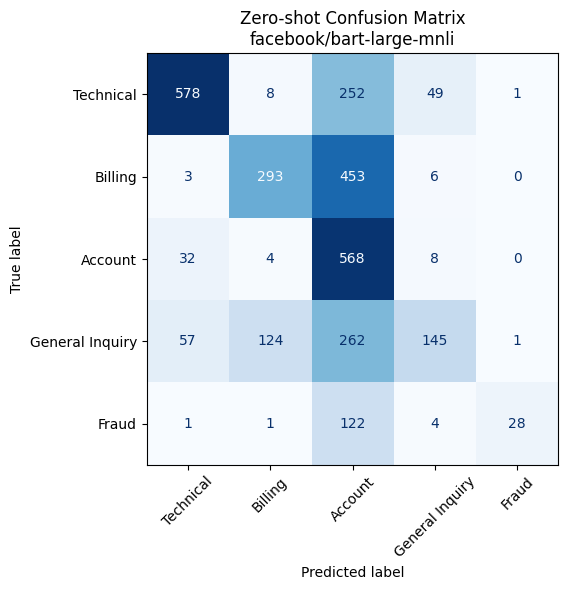

                 Technical  Billing  Account  General Inquiry  Fraud
Technical              578        8      252               49      1
Billing                  3      293      453                6      0
Account                 32        4      568                8      0
General Inquiry         57      124      262              145      1
Fraud                    1        1      122                4     28


In [43]:
# =========================================
# 7. Confusion matrix
# =========================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, pred_labels, labels=label_order)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title(f"Zero-shot Confusion Matrix\n{CHECKPOINT}")
plt.tight_layout()
plt.show()

cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)
print(cm_df)

In [44]:
# =========================================
# 8. Multiclass ROC-AUC (OvR)
# =========================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_true_bin = label_binarize(y_true, classes=label_order)

auc_macro_ovr = roc_auc_score(
    y_true_bin,
    score_matrix,
    multi_class='ovr',
    average='macro'
)

auc_weighted_ovr = roc_auc_score(
    y_true_bin,
    score_matrix,
    multi_class='ovr',
    average='weighted'
)

print(f"ROC-AUC Macro OvR:    {auc_macro_ovr:.4f}")
print(f"ROC-AUC Weighted OvR: {auc_weighted_ovr:.4f}")

ROC-AUC Macro OvR:    0.8489
ROC-AUC Weighted OvR: 0.8633


In [45]:
# =========================================
# 9. Summary table
# =========================================
results_summary = pd.DataFrame({
    "model_type": ["zero_shot"],
    "checkpoint": [CHECKPOINT],
    "input_text": ["text_combined"],
    "labels_type": ["simple_labels"],
    "accuracy": [acc],
    "macro_f1": [f1_macro],
    "weighted_f1": [f1_weighted],
    "auc_macro_ovr": [auc_macro_ovr],
    "auc_weighted_ovr": [auc_weighted_ovr]
}).round(4)

print(results_summary)

  model_type                checkpoint     input_text    labels_type  \
0  zero_shot  facebook/bart-large-mnli  text_combined  simple_labels   

   accuracy  macro_f1  weighted_f1  auc_macro_ovr  auc_weighted_ovr  
0    0.5373      0.48       0.5328         0.8489            0.8633  


### elaborated labels

In [52]:
# =========================================
# Zero-shot with elaborated labels
# =========================================

elaborated_labels = [
    "Technical issue such as software bug, API failure, system malfunction, installation problem, or feature not working properly",
    "Billing issue such as refund request, invoice problem, payment failure, charge dispute, or subscription payment question",
    "Account issue such as password reset, login credentials, profile update, account settings, two-factor authentication, or account access management",
    "General inquiry such as product information request, pricing question, demo request, discount inquiry, or general support question",
    "Fraud or security issue such as suspicious login, compromised account, unusual device access, unauthorized card activity, or security alert"
]

elaborated_to_original = {
    elaborated_labels[0]: "Technical",
    elaborated_labels[1]: "Billing",
    elaborated_labels[2]: "Account",
    elaborated_labels[3]: "General Inquiry",
    elaborated_labels[4]: "Fraud"
}

In [54]:
# =========================================
# Run zero-shot with elaborated labels
# =========================================
pred_labels_elab = []
score_matrix_elab = []

hypothesis_template = "This text is about {}."

for text in tqdm(texts):
    result = zero_shot_clf(
        text,
        candidate_labels=elaborated_labels,
        hypothesis_template=hypothesis_template,
        multi_label=False
    )
    
    result_scores = dict(zip(result['labels'], result['scores']))
    aligned_scores = [result_scores[label] for label in elaborated_labels]
    score_matrix_elab.append(aligned_scores)
    
    pred_label_elab = elaborated_to_original[elaborated_labels[np.argmax(aligned_scores)]]
    pred_labels_elab.append(pred_label_elab)

score_matrix_elab = np.array(score_matrix_elab)

  0%|          | 0/3000 [00:00<?, ?it/s]

In [55]:
# =========================================
# Evaluate elaborated labels
# =========================================
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

acc_elab = accuracy_score(y_true, pred_labels_elab)
f1_macro_elab = f1_score(y_true, pred_labels_elab, average='macro')
f1_weighted_elab = f1_score(y_true, pred_labels_elab, average='weighted')

print(f"Accuracy:    {acc_elab:.4f}")
print(f"Macro F1:    {f1_macro_elab:.4f}")
print(f"Weighted F1: {f1_weighted_elab:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, pred_labels_elab, labels=label_order, digits=4))

cm_elab = confusion_matrix(y_true, pred_labels_elab, labels=label_order)
print("\nConfusion Matrix:")
print(pd.DataFrame(cm_elab, index=label_order, columns=label_order))

y_true_bin = label_binarize(y_true, classes=label_order)

auc_macro_elab = roc_auc_score(
    y_true_bin,
    score_matrix_elab,
    multi_class='ovr',
    average='macro'
)

auc_weighted_elab = roc_auc_score(
    y_true_bin,
    score_matrix_elab,
    multi_class='ovr',
    average='weighted'
)

print(f"\nROC-AUC Macro OvR:    {auc_macro_elab:.4f}")
print(f"ROC-AUC Weighted OvR: {auc_weighted_elab:.4f}")

Accuracy:    0.7597
Macro F1:    0.7228
Weighted F1: 0.7779

Classification Report:
                 precision    recall  f1-score   support

      Technical     0.7396    0.9437    0.8293       888
        Billing     0.9869    0.6980    0.8177       755
        Account     0.9406    0.5948    0.7287       612
General Inquiry     0.9518    0.6706    0.7869       589
          Fraud     0.2919    0.9936    0.4512       156

       accuracy                         0.7597      3000
      macro avg     0.7822    0.7801    0.7228      3000
   weighted avg     0.8612    0.7597    0.7779      3000


Confusion Matrix:
                 Technical  Billing  Account  General Inquiry  Fraud
Technical              838        0       20                0     30
Billing                 56      527        0                6    166
Account                 69        3      364               13    163
General Inquiry        170        4        3              395     17
Fraud                    0        0 

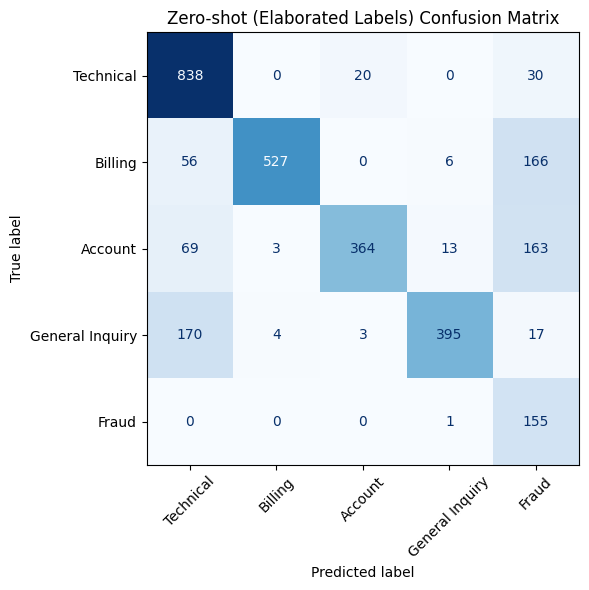

                 Technical  Billing  Account  General Inquiry  Fraud
Technical              838        0       20                0     30
Billing                 56      527        0                6    166
Account                 69        3      364               13    163
General Inquiry        170        4        3              395     17
Fraud                    0        0        0                1    155


In [65]:
# =========================================
# Confusion Matrix (Elaborated Labels - colored)
# =========================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# שימוש בתחזיות של elaborated
cm_elab = confusion_matrix(y_true, pred_labels_elab, labels=label_order)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_elab,
    display_labels=label_order
)

disp.plot(
    ax=ax,
    cmap='Blues',          # אותו צבע כמו שביקשת
    xticks_rotation=45,
    colorbar=False
)

plt.title("Zero-shot (Elaborated Labels) Confusion Matrix")
plt.tight_layout()
plt.show()

# טבלה להדפסה (כמו קודם)
cm_elab_df = pd.DataFrame(cm_elab, index=label_order, columns=label_order)
print(cm_elab_df)

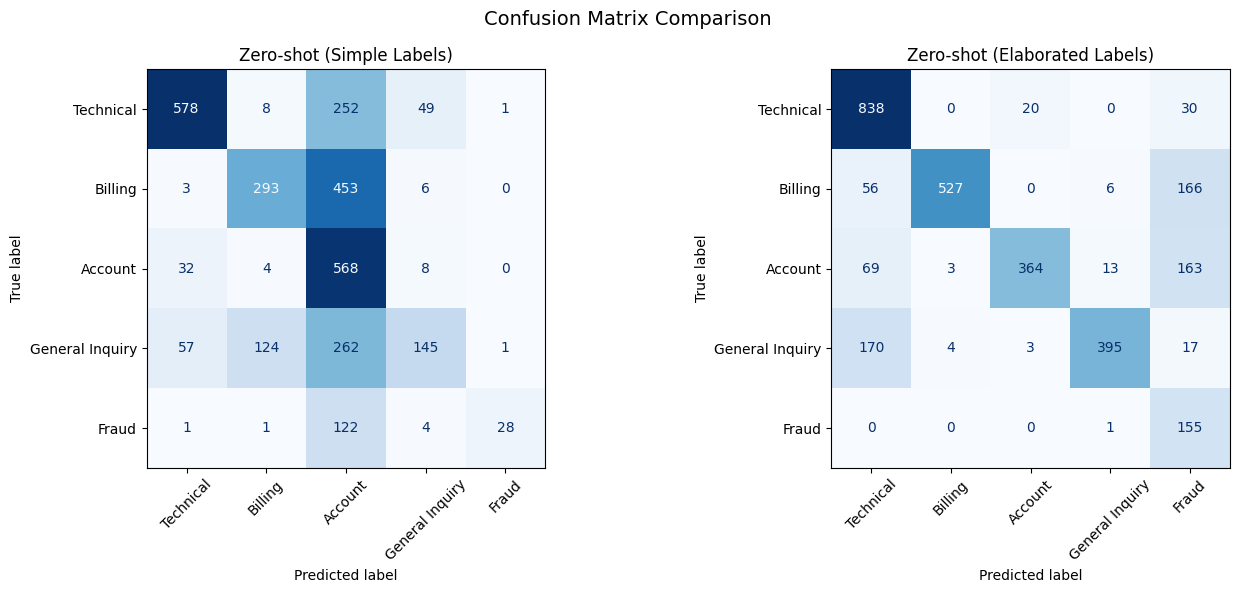

In [67]:
# =========================================
# Side-by-side Confusion Matrices
# Simple vs Elaborated
# =========================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = label_order

# Simple
cm_simple = confusion_matrix(y_true, pred_labels, labels=labels)

# Elaborated
cm_elab = confusion_matrix(y_true, pred_labels_elab, labels=labels)

# יצירת Figure עם 2 תתי גרפים
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ===== Left: Simple =====
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm_simple,
    display_labels=labels
)

disp1.plot(
    ax=axes[0],
    cmap='Blues',
    xticks_rotation=45,
    colorbar=False
)

axes[0].set_title("Zero-shot (Simple Labels)")

# ===== Right: Elaborated =====
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_elab,
    display_labels=labels
)

disp2.plot(
    ax=axes[1],
    cmap='Blues',
    xticks_rotation=45,
    colorbar=False
)

axes[1].set_title("Zero-shot (Elaborated Labels)")

# כותרת כללית
plt.suptitle("Confusion Matrix Comparison", fontsize=14)

plt.tight_layout()
plt.show()

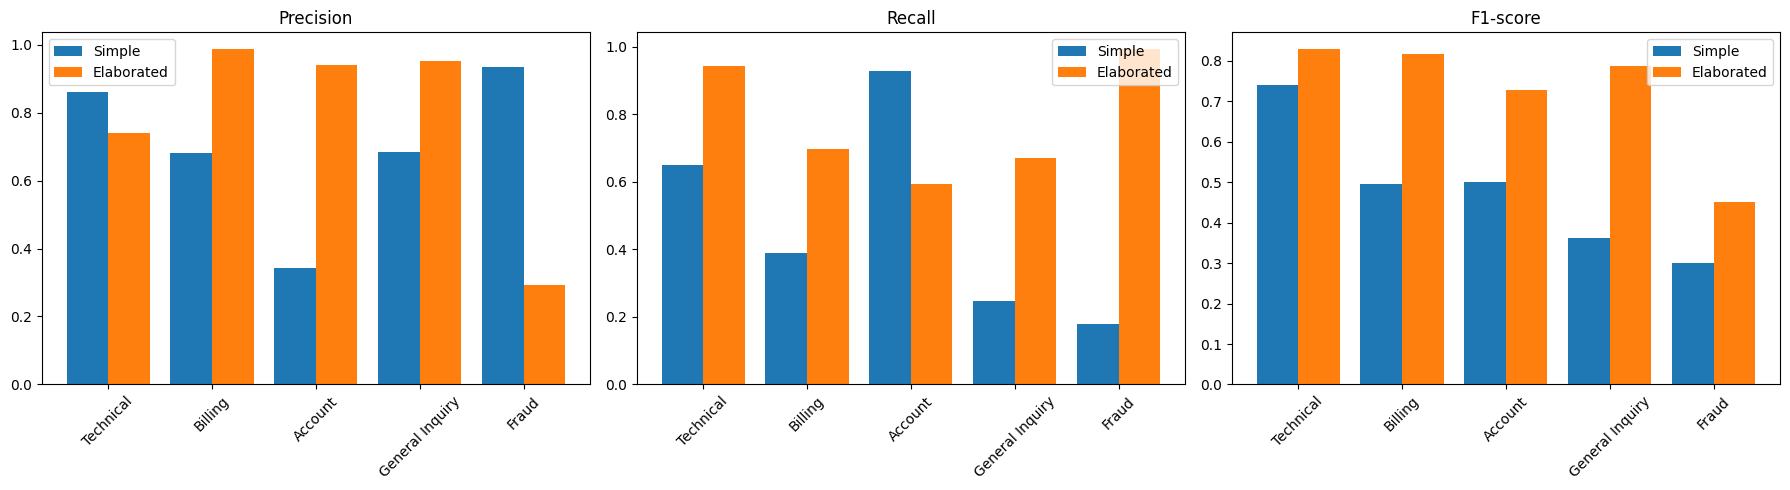

In [71]:
# =========================================
# Per-class metrics comparison
# =========================================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Reports
report_simple = classification_report(y_true, pred_labels, output_dict=True)
report_elab = classification_report(y_true, pred_labels_elab, output_dict=True)

labels = label_order

metrics = ['precision', 'recall', 'f1-score']

data_plot = []

for label in labels:
    for metric in metrics:
        data_plot.append({
            'label': label,
            'metric': metric,
            'Simple': report_simple[label][metric],
            'Elaborated': report_elab[label][metric]
        })

df_plot = pd.DataFrame(data_plot)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics):
    subset = df_plot[df_plot['metric'] == metric]
    
    x = range(len(labels))
    axes[i].bar(x, subset['Simple'], width=0.4, label='Simple', align='center')
    axes[i].bar([p + 0.4 for p in x], subset['Elaborated'], width=0.4, label='Elaborated')
    
    axes[i].set_xticks([p + 0.2 for p in x])
    axes[i].set_xticklabels(labels, rotation=45)
    axes[i].set_title(metric.capitalize())
    axes[i].legend()

plt.tight_layout()
plt.show()

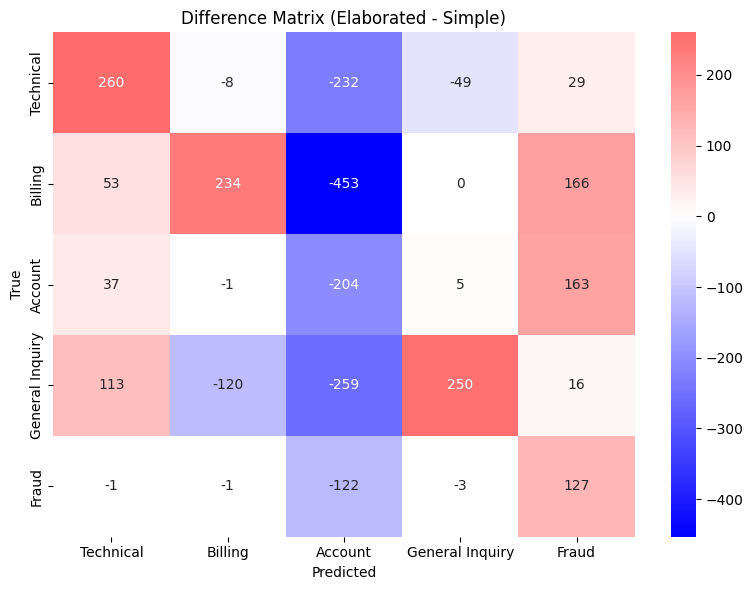

In [73]:
# =========================================
# Difference Confusion Matrix
# (Elaborated - Simple)
# =========================================
import seaborn as sns

diff_cm = cm_elab - cm_simple

plt.figure(figsize=(8, 6))
sns.heatmap(
    diff_cm,
    annot=True,
    fmt='d',
    xticklabels=label_order,
    yticklabels=label_order,
    cmap='bwr',   # כחול-אדום
    center=0
)

plt.title("Difference Matrix (Elaborated - Simple)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

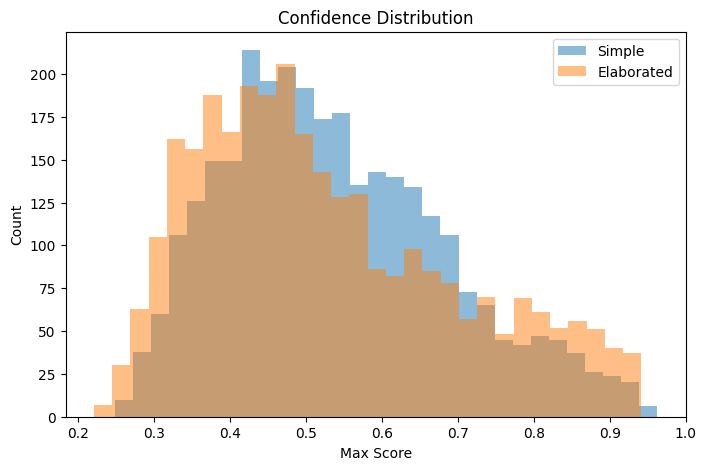

In [75]:
# =========================================
# Confidence comparison
# =========================================

max_scores_simple = score_matrix.max(axis=1)
max_scores_elab = score_matrix_elab.max(axis=1)

plt.figure(figsize=(8,5))
plt.hist(max_scores_simple, bins=30, alpha=0.5, label='Simple')
plt.hist(max_scores_elab, bins=30, alpha=0.5, label='Elaborated')

plt.title("Confidence Distribution")
plt.xlabel("Max Score")
plt.ylabel("Count")
plt.legend()
plt.show()

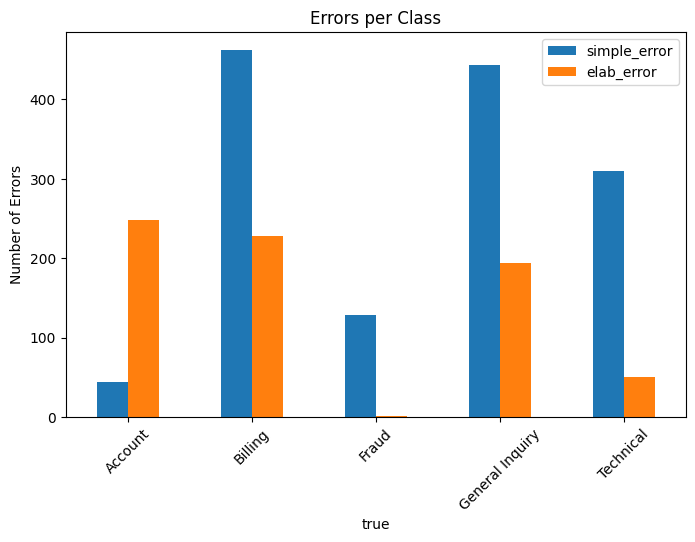

In [77]:
# =========================================
# Error count per class
# =========================================

errors_simple = (pd.Series(y_true) != pd.Series(pred_labels))
errors_elab = (pd.Series(y_true) != pd.Series(pred_labels_elab))

df_err = pd.DataFrame({
    'true': y_true,
    'simple_error': errors_simple,
    'elab_error': errors_elab
})

err_summary = df_err.groupby('true').sum()

err_summary.plot(kind='bar', figsize=(8,5))
plt.title("Errors per Class")
plt.ylabel("Number of Errors")
plt.xticks(rotation=45)
plt.show()

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_cms(cms, titles):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    categories = ['Account', 'Billing', 'Fraud', 'Inquiry', 'Tech']
    
    for i, (cm, title) in enumerate(zip(cms, titles)):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=categories, yticklabels=categories, cbar=False)
        axes[i].set_title(title, fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
        
    plt.tight_layout()
    plt.savefig("confusion_matrices_evolution.png", dpi=300)
    plt.show()

# כאן אתה צריך להציב את המטריצות האמיתיות שקיבלת מהקוד שלך
# cms = [cm_naive, cm_elaborated, cm_finetuned]
# plot_cms(cms, ["Naive Zero-Shot", "Elaborated ZSL", "Fine-Tuned BART"])